# This script computes the median and maximum drought days experienced by each LAU and NUTS-3 between 2012 and 2026
It uses the coverage statistics computed in the previous step and combines them with the CDI dataset


In [1]:
import numpy as np
import re
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import rasterio
import glob
import os
import utils

from tqdm.notebook import tqdm

tqdm.pandas()

In [2]:
cdi_files = sorted(
    glob.glob(
        os.path.join(
            utils.raw_data_dir, "combined_drought_indicator_2012-2025", "**", "*.tif"
        )
    )
)
cdi_folders = sorted(
    glob.glob(
        os.path.join(utils.raw_data_dir, "combined_drought_indicator_2012-2025", "*")
    )
)

# like before, toggle this variable to switch between LAU and NUTS-3 level of analysis
LAU_level = False
if LAU_level:
    coverage_files = glob.glob(
        os.path.join(
            utils.intermediate_data_dir, "cdi_raster_coverage_lau", "*.geojson"
        )
    )
    out_file = "drought_days_lau.geojson"
else:
    coverage_files = glob.glob(
        os.path.join(
            utils.intermediate_data_dir, "cdi_raster_coverage_nuts3", "*.geojson"
        )
    )
    out_file = "drought_days_nuts3.geojson"

In [3]:
# load all country-files into a single DataFrame
df = [gpd.read_file(f) for f in coverage_files]
lau_crs = df[0].crs

df = gpd.GeoDataFrame(pd.concat(df, ignore_index=True))
df = df.set_crs(lau_crs)

In [4]:
# load the first cdi file to extract metadata
with rasterio.open(cdi_files[0]) as src:
    geotiff = src.read(1)
    cdi_dims = src.read(1).shape

    assert src.crs == lau_crs

    # compute pixel indices in the raster for each pair of x/y coordinates
    min_coords = np.array(
        [src.index(x, y) for x, y in df[["xmin", "ymin"]].values.astype(float)]
    )
    max_coords = np.array(
        [src.index(x, y) for x, y in df[["xmax", "ymax"]].values.astype(float)]
    )


# enter pixel indieces into the dataframe for later reference
df["row_start"] = min_coords[:, 0]
df["col_start"] = min_coords[:, 1]
df["row_end"] = max_coords[:, 0]
df["col_end"] = max_coords[:, 1]

In [5]:
# minor type cleanup
for col in ["col_start", "col_end", "row_start", "row_end"]:
    df[col] = df[col].astype(int)
df["cell_coverage"] = df["cell_coverage"].apply(lambda x: np.array(eval(x)))


def calculate_cell_weights(cell_coverage):
    # by default, exactextract returns the fraction of each grid cell that is being covered by the polygon.
    # We however desire the inverse: How much of the Polygon's area lies in a given grid cell
    # The latter allows us to weigh grid values to determine the average value inside the LAU
    total_coverage = cell_coverage.sum(axis=None)
    return cell_coverage / total_coverage


df["cell_weights"] = df["cell_coverage"].apply(calculate_cell_weights)

In [6]:
# compute two 3D-matrices containing the total number of "warning" and "alert" days per pixel in the CDI raster
warning_days = np.zeros(((2026 - 2012), cdi_dims[0], cdi_dims[1]))
alert_days = np.zeros(((2026 - 2012), cdi_dims[0], cdi_dims[1]))

for i, year in enumerate(range(2012, 2026)):
    print("processing year: ", year)

    year_folder = cdi_folders[i]
    assert bool(
        re.search(f"{year}01\d\d_{year}12", year_folder)
    )  # I messed this up once before so better be safe

    year_files = sorted(glob.glob(os.path.join(year_folder, "*.tif")))
    yearly_data = np.zeros(
        shape=(len(year_files), cdi_dims[0], cdi_dims[1]), dtype=np.uint8
    )

    for file_idx, path in enumerate(year_files):
        with rasterio.open(path) as src:
            yearly_data[file_idx] = src.read(1)

    # value 2 corresponds to CDI level "Warning", value 3 corresponds to level "Alert".
    # See page 3 https://drought.emergency.copernicus.eu/data/factsheets/factsheet_combinedDroughtIndicator_v4.pdf
    cur_year_warning = yearly_data == 2
    warning_days[i] = cur_year_warning.sum(axis=0) * 10

    cur_year_alert = yearly_data == 3
    alert_days[i] = cur_year_alert.sum(axis=0) * 10

processing year:  2012
processing year:  2013
processing year:  2014
processing year:  2015
processing year:  2016
processing year:  2017
processing year:  2018
processing year:  2019
processing year:  2020
processing year:  2021
processing year:  2022
processing year:  2023
processing year:  2024
processing year:  2025


In [7]:
def calculate_yearly_stats(row):
    """generates three sets of arrays for each row in the dataframe: "warning days", "alert days" and their sum: "drought days". For this, it looks at the subgrid of the CDI stats computed in the previous cell.

    Args:
        row (pd.Series): a row in the dataframe, representing either a LAU or NUTS-3

    Returns:
        pd.Series: the same row, including three new columns
    """
    cell_weights = row["cell_weights"]
    width, height = cell_weights.shape

    # NOTE: @factcheck: I messed this up previously. I believe it to be right like this, but all of this dimension swapping can be rather confusing. Please double check.
    x0, x1 = row["row_start"] - width, row["row_start"]
    y0, y1 = row["col_start"], row["col_start"] + height

    # take the subset of the 3D-arrays that overlaps with the shape of this region
    # then, multiply each value by the amount of the total area it comprises
    # finaly, summ over axes 2 and 3 to get a 1D-array representing the "warning" and "alert" days per year.
    warning_days_per_year = (
        (warning_days[:, x0:x1, y0:y1] * cell_weights).sum(axis=(1, 2)).round(2)
    )
    alert_days_per_year = (
        (alert_days[:, x0:x1, y0:y1] * cell_weights).sum(axis=(1, 2)).round(2)
    )

    row["warning_days"] = warning_days_per_year.tolist()
    row["alert_days"] = alert_days_per_year.tolist()
    row["drought_days"] = (
        (warning_days_per_year + alert_days_per_year).round(2).tolist()
    )
    return row


print("calculating yearly stats...")
df = df.progress_apply(calculate_yearly_stats, axis=1)

calculating yearly stats...


  0%|          | 0/1507 [00:00<?, ?it/s]

In [8]:
# compute median value, maximum value and the year that the maximum value occurred for each of the three metrices
for value in ["warning", "alert", "drought"]:
    df[f"median_{value}_days"] = df[f"{value}_days"].apply(
        lambda x: np.median(x).round(2)
    )
    df[f"max_{value}_days"] = df[f"{value}_days"].apply(lambda x: np.max(x).round(2))
    df[f"max_{value}_days_year"] = df[f"{value}_days"].apply(
        lambda x: 2012 + np.argmax(x)
    )

In [9]:
# drop columns that are no longer needed
if LAU_level:
    out_data = gpd.GeoDataFrame(
        df[
            [
                "CNTR_CODE",
                "LAU_NAME",
                "geometry",
                "warning_days",
                "median_warning_days",
                "max_warning_days",
                "max_warning_days_year",
                "alert_days",
                "median_alert_days",
                "max_alert_days",
                "max_alert_days_year",
                "drought_days",
                "median_drought_days",
                "max_drought_days",
                "max_drought_days_year",
            ]
        ]
    )
else:
    out_data = gpd.GeoDataFrame(
        df[
            [
                "NUTS_ID",
                "CNTR_CODE",
                "NAME_LATN",
                "NUTS_NAME",
                "geometry",
                "warning_days",
                "median_warning_days",
                "max_warning_days",
                "max_warning_days_year",
                "alert_days",
                "median_alert_days",
                "max_alert_days",
                "max_alert_days_year",
                "drought_days",
                "median_drought_days",
                "max_drought_days",
                "max_drought_days_year",
            ]
        ]
    )

out_data = out_data.to_crs(epsg=4326)
out_data.to_file(os.path.join(utils.out_data_dir, out_file))

# Sanity check: plot the warning days as an indicator that we are producing sensible data

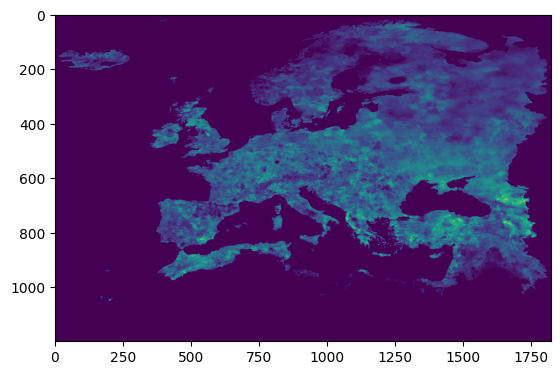

In [10]:
plt.imshow(warning_days.sum(axis=0))

# Sanity check: Plot some weight matrices and their corresponding shapefiles to validate that the overlap computation makes sense

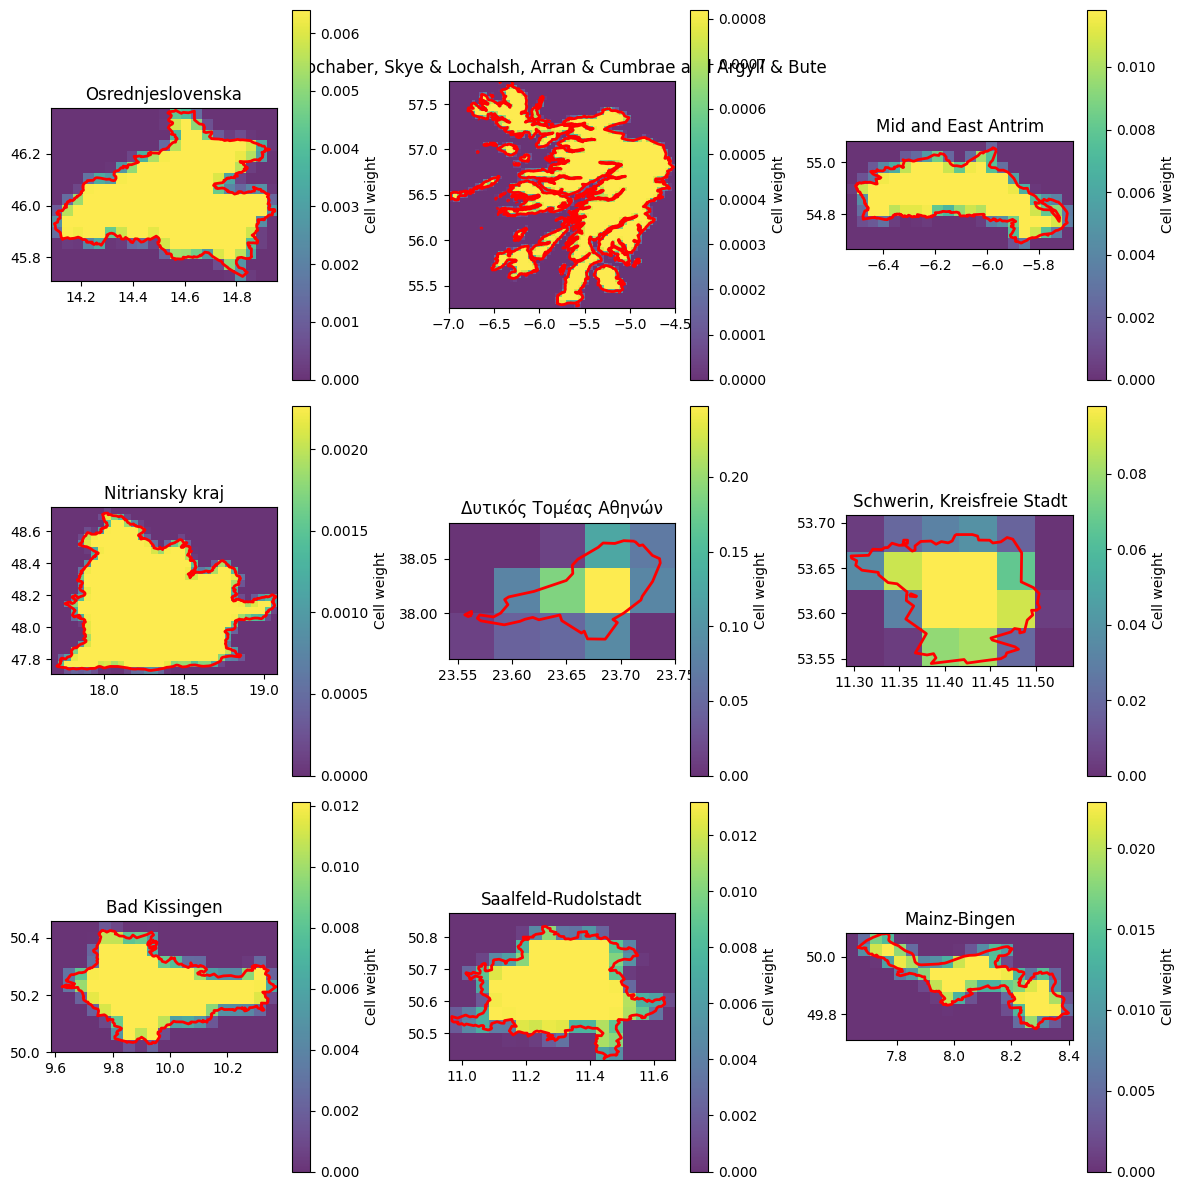

In [11]:
# --- Plot ---
fig, axs = plt.subplots(3, 3, figsize=(12, 12), squeeze=True)
axs = axs.flatten()

for i, ax in enumerate(axs):
    temp = df.iloc[np.random.randint(100) + (i * 100)]
    col_start = temp["col_start"]
    col_end = temp["col_end"]
    row_start = temp["row_start"]
    row_end = temp["row_end"]

    cell_weights = temp["cell_weights"]

    tif_local = geotiff[row_start:row_end, col_start:col_end]
    # 1. Show raster using extent [x_min, x_max, y_min, y_max]
    im = ax.imshow(
        cell_weights,
        extent=[temp["xmin"], temp["xmax"], temp["ymin"], temp["ymax"]],
        cmap="viridis",
        alpha=0.8,
    )

    gpd.GeoSeries(temp.geometry).plot(
        ax=ax, facecolor="none", edgecolor="red", linewidth=2
    )

    plt.colorbar(im, ax=ax, label="Cell weight")
    if LAU_level:
        ax.set_title(temp["LAU_NAME"])
    else:
        ax.set_title(temp["NUTS_NAME"])
plt.tight_layout()
plt.show()